# Example 8: Inter-Satellite-Link (ISL) Orbit Determination and Timing System (ODTS)

This notebook runs an onboard ODTS analysis for the full **5-satellite** constellation
from NASA's
[Lunar Communications Relay and Navigation Systems (LCRNS) Reference Constellation 3.1](https://www.nasa.gov/wp-content/uploads/2025/08/nasa-lunar-communications-relay-and-navigation-systems-lcrns-reference-constellation-3-1.pdf)
(Ryden & Volle, NASA GSFC) -- five satellites in Elliptical Lunar Frozen Orbits (ELFO).
One satellite (`SV-1`) is the **hub**: it receives the LCRNS crosslink signal from each
of the other four and runs a single onboard **Schmidt Extended Kalman Filter
(Schmidt-EKF)**:

- **Estimated state** (8 states): the hub's own `[position, velocity, clock bias,
  clock drift]`.
- **Consider states** (4 &times; 8 = 32 states): each of the *other four* satellites'
  `[position, velocity, clock bias, clock drift]` -- included in the filter's
  covariance bookkeeping (and hence in the measurement partials/Kalman gain) but never
  directly corrected, since the hub only has a broadcast/prior estimate of its
  neighbors, not full estimation authority over them.
- **Measurement**: two-way range and Doppler (range-rate) on each of the **four
  crosslinks** (`SV-1<->SV-2`, `SV-1<->SV-3`, `SV-1<->SV-4`, `SV-1<->SV-5`), once per
  epoch. A coherent two-way (transponder) crosslink is unbiased by either end's clock
  offset to first order, so each observable reduces to the geometric relative range and
  range-rate (see `lupnt::RangeAndRangeRate`).

The simulation class (`lupnt::IslOdtsSimulation`,
`cpp/lupnt/simulations/IslOdts/isl_odts_simulation.h`) and the `SchmidtEKF` consider-
state filter (`cpp/lupnt/filters/schmidt_ekf.h`) generalize to **N satellites**: any
one satellite can be designated the hub, with a crosslink (and one consider-state
block) for each of the other N-1. A simplified free-space crosslink link budget
(`IslLinkBudgetConfig`) is also computed and reported per link for context -- full
antenna-gain-pattern link-budget analysis (as done for GNSS links via
`lupnt.GnssMeasurement`/`lupnt.Antenna`) is not performed here, but the same
infrastructure could be attached to this simulation if needed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import pylupnt as pnt

np.random.seed(0)

[00.00][PyLuPNT] Initializing


## 1. LCRNS Reference Constellation -- all five satellites

The LCRNS reference document provides five ELFO satellite states at the reference
epoch **2027-03-01 00:00:00.000 UTC**, in the Moon-centered ICRF (Table 2 of the
reference). `SV-1` and `SV-2` share one orbit plane (~180&deg; apart in true anomaly);
`SV-3` and `SV-4` share a second plane; `SV-5` occupies a third. We use these Cartesian
states directly (so no Keplerian-element/frame-convention assumptions are needed) as
the truth trajectories for all five satellites, with `SV-1` as the hub. The orbit
period is approximately 30 hours for all five.

In [2]:
t0_str = "2027-03-01T00:00:00"  # UTC, LCRNS Reference Constellation 3.1 epoch

# NASA LCRNS Reference Constellation 3.1 (Ryden & Volle, NASA GSFC), Table 2:
# Cartesian initial states in the Moon-centered ICRF, [km], [km/s]. SV-1 is the hub.
lcrns_states_km = {
    "SV-1": ([-198.931445, 386.023132, 3458.355412], [-1.539867, 0.022243, -0.091059]),
    "SV-2": ([1089.980598, -2260.918271, -18984.562823], [0.280301, -0.004049, 0.016575]),
    "SV-3": ([9187.665852, -260.470721, -8543.222759], [0.273629, 0.417588, -0.313828]),
    "SV-4": ([6484.019002, 14329.883921, -7966.345594], [-0.258433, 0.033951, 0.235264]),
    "SV-5": ([-5074.242314, 14473.022751, -8638.530033], [-0.229931, -0.026926, -0.264381]),
}

# LCRNS clock offsets are not specified in the reference document; assign small,
# distinct representative offsets so the crosslinks are not perfectly clock-synced.
clock_bias_s = {"SV-1": 0.0, "SV-2": 10e-6, "SV-3": -6e-6, "SV-4": 4e-6, "SV-5": -8e-6}
clock_drift_sps = {"SV-1": 0.0, "SV-2": 1e-10, "SV-3": -8e-11, "SV-4": 5e-11, "SV-5": -3e-11}

satellites = []
for name, (r_km, v_kmps) in lcrns_states_km.items():
    sat = pnt.IslOdtsSatelliteConfig()
    sat.name = name
    sat.r0_m = np.array(r_km) * 1e3
    sat.v0_mps = np.array(v_kmps) * 1e3
    sat.clock_bias_s = clock_bias_s[name]
    sat.clock_drift_sps = clock_drift_sps[name]
    satellites.append(sat)

a_m = 11316.94e3  # SMA from Table 1 (SV-1), used only to report the orbit period
period_h = 2 * np.pi * np.sqrt(a_m**3 / pnt.GM_MOON) / 3600.0
for sat in satellites:
    print(f"{sat.name}: |r0| = {np.linalg.norm(sat.r0_m) / 1e3:8.1f} km")
print(f"ELFO period ~ {period_h:.1f} h; hub = {satellites[0].name}, "
      f"{len(satellites) - 1} crosslinks")

SV-1: |r0| =   3485.5 km
SV-2: |r0| =  19149.8 km
SV-3: |r0| =  12548.6 km
SV-4: |r0| =  17631.0 km
SV-5: |r0| =  17602.3 km
ELFO period ~ 30.0 h; hub = SV-1, 4 crosslinks


## 2. ISL ODTS Configuration

The **truth** trajectories are propagated with a higher-fidelity lunar gravity field
(plus Earth/Sun third-body and relativistic corrections); the hub's onboard **filter**
propagates its own state and every consider (neighbor) state with a reduced-order
gravity field, mirroring a realistic onboard force model. The crosslinks are simulated
for about a fifth of one ELFO period, long enough to see the estimation-error behavior
without a long runtime.

In [ ]:
cfg = pnt.IslOdtsConfig()
cfg.seed = 42
cfg.start_epoch_utc = t0_str
cfg.duration_s = 6.0 * 3600.0  # [s]
cfg.dt_s = 60.0                # [s] crosslink measurement interval
cfg.integration_step_s = 60.0  # [s]

cfg.satellites = satellites  # [0] = hub (SV-1), [1:] = linked satellites (SV-2..SV-5)

# Truth force model
cfg.moon_gravity_degree_truth = 16
cfg.moon_gravity_order_truth = 16
cfg.include_earth = True
cfg.include_sun = True
cfg.use_relativity = True

# Onboard filter force model (reduced-order; STM via autodiff)
cfg.moon_gravity_degree_filter = 8
cfg.moon_gravity_order_filter = 8

# Two-way crosslink measurement noise (applied identically to every link)
cfg.range_sigma_m = 1.0            # [m]
cfg.range_rate_sigma_mps = 1.0e-3  # [m/s]

# Onboard Schmidt-EKF: hub's own (estimated) state initial uncertainty
cfg.initial_position_sigma_m = 200.0
cfg.initial_velocity_sigma_mps = 0.1
cfg.initial_clock_bias_sigma_s = 1.0e-6
cfg.initial_clock_drift_sigma_sps = 1.0e-9

# ... and each considered (never corrected) neighbor-state uncertainty, e.g. from a
# periodically refreshed broadcast/prior ephemeris
cfg.consider_position_sigma_m = 10.0
cfg.consider_velocity_sigma_mps = 0.001
cfg.consider_clock_bias_sigma_s = 1.0e-7
cfg.consider_clock_drift_sigma_sps = 1.0e-10

cfg.process_accel_sigma_mps2 = 1.0e-8

# Simplified free-space crosslink link budget, for reporting only (not used by the
# filter) -- representative Ka-band crosslink parameters (the LCRNS reference document
# does not specify RF parameters).
cfg.link_budget.enabled = True
cfg.link_budget.tx_power_dbw = 5.0
cfg.link_budget.tx_gain_dbi = 20.0
cfg.link_budget.rx_gain_dbi = 20.0
cfg.link_budget.frequency_hz = 25.5e9
cfg.link_budget.system_noise_temp_k = 500.0

In [4]:
sim = pnt.IslOdtsSimulation(cfg)
sim.setup()
sim.run()
res = sim.get_results()

t_h = res.t_s / 3600.0
n_sat = len(res.satellite_names)
n_links = n_sat - 1
link_names = res.satellite_names[1:]
print(f"Ran {len(t_h)} epochs over {t_h[-1]:.2f} hours "
      f"({cfg.dt_s:.0f} s crosslink measurement interval)")
print(f"Hub: {res.satellite_names[0]}   Links: {link_names}")
print(f"Filter state size: {res.est.shape[1]} (own 8 + {n_links} x consider 8)")



  0%|          | 0/360 [00:00<00:00, 0.0 it/s]

[00.07] ISL ODTS   0%|          | 0/360 [00:00<00:00, 0.0 it/s]
Ran 361 epochs over 6.00 hours (60 s crosslink measurement interval)
Hub: SV-1   Links: ['SV-2', 'SV-3', 'SV-4', 'SV-5']
Filter state size: 40 (own 8 + 4 x consider 8)

[00.07] ISL ODTS   6%|          | 24/360 [00:00<00:02, 119.8 it/s]

[00.07] ISL ODTS  41%|████      | 149/360 [00:00<00:00, 371.3 it/s]

[00.07] ISL ODTS  80%|████████  | 290/360 [00:00<00:00, 481.4 it/s]

[00.07] ISL ODTS 100%|██████████| 360/360 [00:00<00:00, 511.7 it/s]

[00.07] ISL ODTS 100%|██████████| 360/360 [00:00<00:00, 511.6 it/s]


## 3. Plot 1 -- Orbits and crosslink geometry

The five ELFO trajectories over the simulated arc, and the four ISL crosslinks
connecting the hub (`SV-1`) to each other satellite at a handful of sampled epochs.

In [ ]:
sat_colors = ["#1F77B4", "#D62728", "#2CA02C", "#9467BD", "#8C564B"]
link_colors = sat_colors[1:]

fig = go.Figure()
pnt.plot.plot_body(fig, pnt.MOON)
pnt.plot.plot_orbits(
    fig,
    np.stack([ts[:, :6] for ts in res.truth_states]),
    t=0,
    color=sat_colors,
)

n_link_samples = 6
link_idx = np.linspace(0, len(t_h) - 1, n_link_samples).astype(int)
hub_pos = res.truth_states[0][:, :3]
for i in range(n_links):
    neighbor_pos = res.truth_states[i + 1][:, :3]
    for j, k in enumerate(link_idx):
        fig.add_trace(
            go.Scatter3d(
                x=[hub_pos[k, 0], neighbor_pos[k, 0]],
                y=[hub_pos[k, 1], neighbor_pos[k, 1]],
                z=[hub_pos[k, 2], neighbor_pos[k, 2]],
                mode="lines",
                line=dict(color=link_colors[i], width=3),
                opacity=0.6,
                showlegend=(j == 0),
                name=f"{res.satellite_names[0]} to {link_names[i]}",
            )
        )

pnt.plot.set_view(fig, azimuth=-35, elevation=15, zoom=2.2)
fig.update_layout(
    title=f"LCRNS constellation ELFO trajectories and {res.satellite_names[0]} ISL crosslinks "
          f"({t_h[-1]:.1f} h arc)",
    height=700,
    showlegend=True,
)
fig.show()

## 4. Plot 2 -- Observed two-way range, Doppler, and crosslink C/N0

Simulated two-way range/range-rate observations and the simplified crosslink
carrier-to-noise density ratio for each of the four `SV-1` crosslinks.

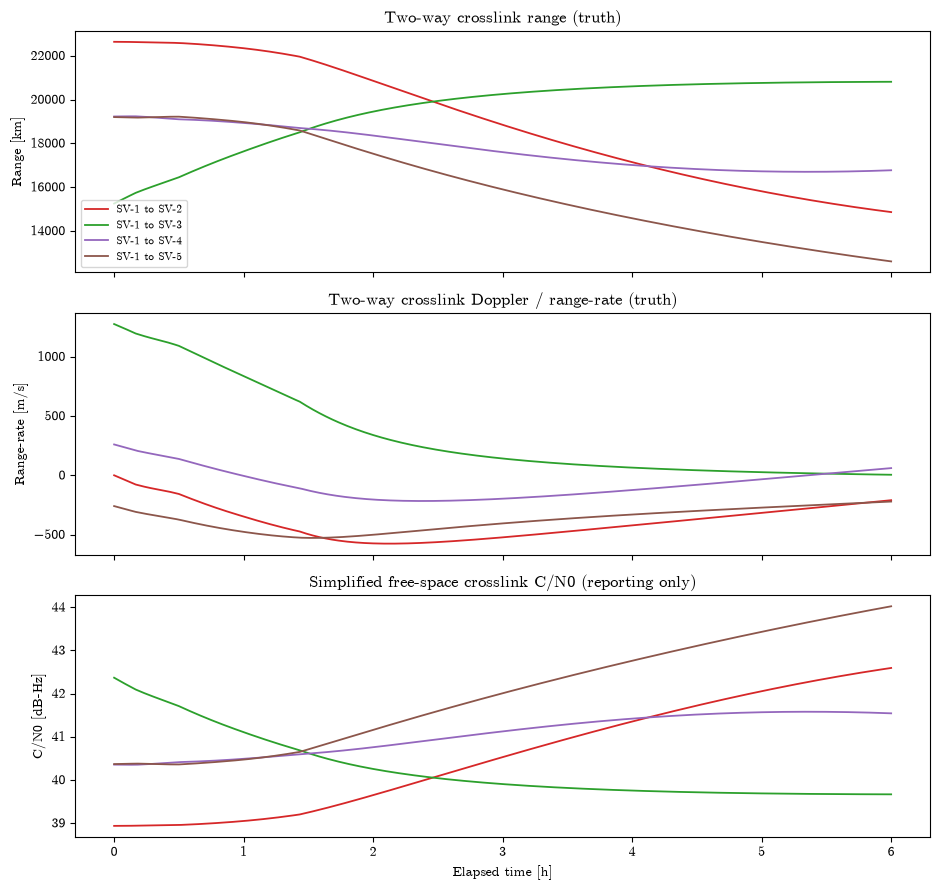

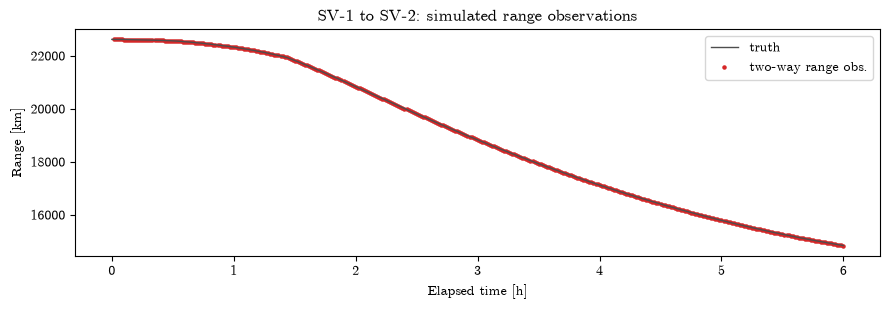

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(9.5, 9), sharex=True)

for i in range(n_links):
    color = link_colors[i]
    label = f"{res.satellite_names[0]} to {link_names[i]}"
    axes[0].plot(t_h, res.range_true_m[:, i] / 1e3, color=color, lw=1.3, label=label)
    axes[1].plot(t_h, res.range_rate_true_mps[:, i], color=color, lw=1.3, label=label)
    axes[2].plot(t_h, res.cn0_dbhz[:, i], color=color, lw=1.3, label=label)

axes[0].set_ylabel("Range [km]")
axes[0].set_title("Two-way crosslink range (truth)")
axes[0].legend(loc="best", fontsize=8)

axes[1].set_ylabel("Range-rate [m/s]")
axes[1].set_title("Two-way crosslink Doppler / range-rate (truth)")

axes[2].set_ylabel("C/N0 [dB-Hz]")
axes[2].set_xlabel("Elapsed time [h]")
axes[2].set_title("Simplified free-space crosslink C/N0 (reporting only)")

plt.tight_layout()
plt.show()

# Zoom on one link to show the simulated noisy observations against truth
i_demo = 0
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(t_h, res.range_true_m[:, i_demo] / 1e3, color="0.3", lw=1, label="truth")
ax.scatter(t_h, res.range_obs_m[:, i_demo] / 1e3, s=5, color=link_colors[i_demo],
           label="two-way range obs.")
ax.set_ylabel("Range [km]")
ax.set_xlabel("Elapsed time [h]")
ax.set_title(f"{res.satellite_names[0]} to {link_names[i_demo]}: simulated range observations")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 5. Plot 3 -- ODTS estimation-error convergence

The hub's onboard filter **own-state** position/velocity error against its formal
3&sigma; covariance envelope, and the two-way range/Doppler **pre-fit residuals** on
every crosslink (observed minus the filter's own prediction, evaluated just before
that epoch's update).

A hub with four crosslinks and no external reference (no ground station, no GNSS) has
fundamentally weak *absolute*-position observability: each crosslink directly
constrains only the relative range/range-rate to one neighbor, and the uncertainty
carried by the (never-corrected) consider states also feeds back into the achievable
accuracy of the estimated hub state -- a defining feature of Schmidt-Kalman filtering,
and the reason the formal 3&sigma; envelope grows over time here rather than shrinking
to zero. The pre-fit residuals nonetheless show the filter tracking every crosslink
self-consistently: the *relative* geometry to each neighbor is well determined even
while the hub's *absolute* uncertainty grows.

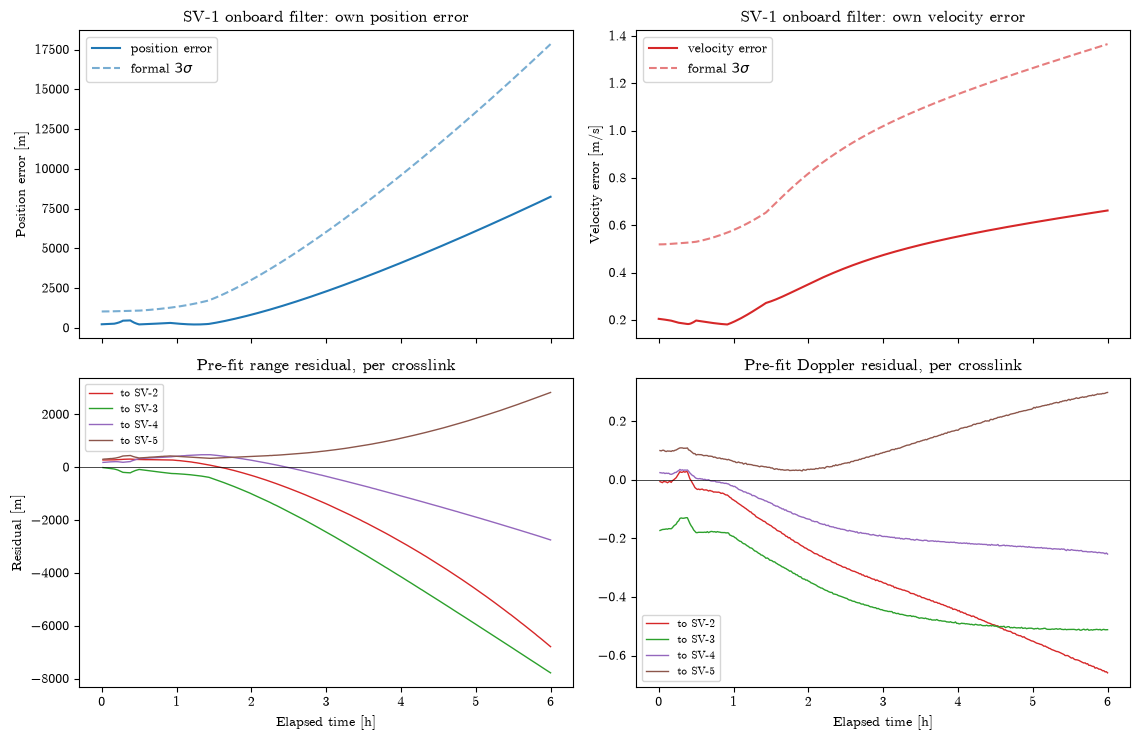

Final SV-1 own position error: 8.25 km (formal 3-sigma: 17.84 km)
Final SV-1 own velocity error: 662.85 mm/s (formal 3-sigma: 1366.05 mm/s)


In [7]:
pos_err = np.linalg.norm(res.truth_states[0][:, :3] - res.est[:, :3], axis=1)
vel_err = np.linalg.norm(res.truth_states[0][:, 3:6] - res.est[:, 3:6], axis=1)
sigma_pos = np.sqrt(res.cov_diag[:, 0] + res.cov_diag[:, 1] + res.cov_diag[:, 2])
sigma_vel = np.sqrt(res.cov_diag[:, 3] + res.cov_diag[:, 4] + res.cov_diag[:, 5])

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.5), sharex=True)

axes[0, 0].plot(t_h, pos_err, color="#1F77B4", label="position error")
axes[0, 0].plot(t_h, 3 * sigma_pos, "--", color="#1F77B4", alpha=0.6, label=r"formal $3\sigma$")
axes[0, 0].set_title(f"{res.satellite_names[0]} onboard filter: own position error")
axes[0, 0].set_ylabel("Position error [m]")
axes[0, 0].legend(loc="upper left")

axes[0, 1].plot(t_h, vel_err, color="#D62728", label="velocity error")
axes[0, 1].plot(t_h, 3 * sigma_vel, "--", color="#D62728", alpha=0.6, label=r"formal $3\sigma$")
axes[0, 1].set_title(f"{res.satellite_names[0]} onboard filter: own velocity error")
axes[0, 1].set_ylabel("Velocity error [m/s]")
axes[0, 1].legend(loc="upper left")

for i in range(n_links):
    color = link_colors[i]
    label = f"to {link_names[i]}"
    axes[1, 0].plot(t_h, res.range_resid_m[:, i], color=color, lw=1, label=label)
    axes[1, 1].plot(t_h, res.range_rate_resid_mps[:, i], color=color, lw=1, label=label)

axes[1, 0].axhline(0.0, color="k", lw=0.5)
axes[1, 0].set_title("Pre-fit range residual, per crosslink")
axes[1, 0].set_ylabel("Residual [m]")
axes[1, 0].set_xlabel("Elapsed time [h]")
axes[1, 0].legend(loc="best", fontsize=8)

axes[1, 1].axhline(0.0, color="k", lw=0.5)
axes[1, 1].set_title("Pre-fit Doppler residual, per crosslink")
axes[1, 1].set_xlabel("Elapsed time [h]")
axes[1, 1].legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()

print(f"Final {res.satellite_names[0]} own position error: {pos_err[-1] / 1e3:.2f} km "
      f"(formal 3-sigma: {3 * sigma_pos[-1] / 1e3:.2f} km)")
print(f"Final {res.satellite_names[0]} own velocity error: {vel_err[-1] * 1e3:.2f} mm/s "
      f"(formal 3-sigma: {3 * sigma_vel[-1] * 1e3:.2f} mm/s)")

## 6. Bonus -- consider-state uncertainty growth per neighbor

Since each of the four neighbors' states is only *considered*, not corrected, its
formal position uncertainty grows through pure dynamics propagation from its (fixed)
initial value -- this directly limits how well the crosslinks can, in turn, constrain
the hub's own state.

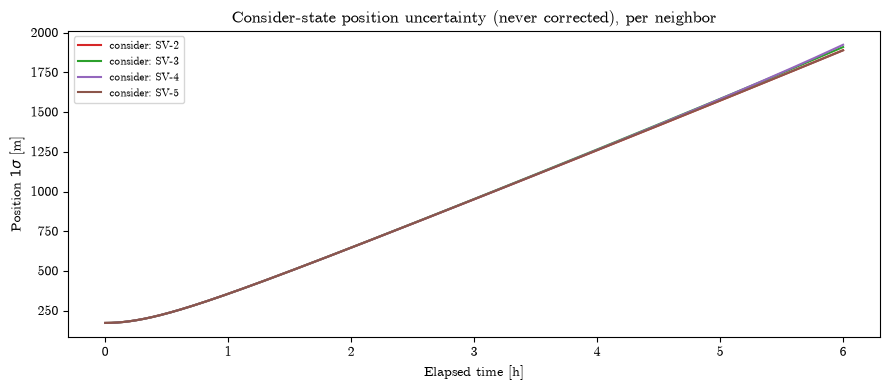

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for i in range(n_links):
    off = 8 * (i + 1)
    sigma_i = np.sqrt(res.cov_diag[:, off] + res.cov_diag[:, off + 1] + res.cov_diag[:, off + 2])
    ax.plot(t_h, sigma_i, color=link_colors[i], label=f"consider: {link_names[i]}")

ax.set_ylabel(r"Position $1\sigma$ [m]")
ax.set_xlabel("Elapsed time [h]")
ax.set_title("Consider-state position uncertainty (never corrected), per neighbor")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()